In [1]:
import yfinance as yf

# Télécharger les données d'Apple (AAPL) du 1er janvier 2020 au 1er janvier 2023
data = yf.download('AAPL', start='2020-01-01', end='2023-01-01')

# Afficher les données (notez que 'print' doit être en minuscules)
print(data)

# Extraire les prix de clôture et les redimensionner
prices = data['Close'].values.reshape(-1, 1)

# Afficher les prix
print(prices)

/tmp/ipython-input-1-3084590504.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2020-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2020-01-02   72.620842   72.681289   71.373218   71.627092  135480400
2020-01-03   71.914803   72.676431   71.689942   71.847102  146322800
2020-01-06   72.487862   72.526549   70.783263   71.034724  118387200
2020-01-07   72.146950   72.753831   71.926922   72.497537  108872000
2020-01-08   73.307503   73.609737   71.849525   71.849525  132079200
...                ...         ...         ...         ...        ...
2022-12-23  130.173782  130.726619  127.982170  129.245801   63814900
2022-12-27  128.367188  129.729545  127.073942  129.699930   69007800
2022-12-28  124.428207  129.354393  124.260383  128.011784   85438400
2022-12-29  127.952553  128.811422  126.096597  126.353267   75703700
2022-12-30  128.268463  128.288212  125.800440  126.767912   77034200

[756 rows x 5 colum

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Créer un scaler pour normaliser les données entre 0 et 1
scaler = MinMaxScaler()

# Appliquer la normalisation aux prix de clôture
scaled = scaler.fit_transform(prices)
print(scaled)

[[0.14679879]
 [0.14111734]
 [0.14572849]
 [0.14298535]
 [0.15232466]
 [0.16485498]
 [0.16621691]
 [0.17911695]
 [0.17078913]
 [0.16818205]
 [0.1757703 ]
 [0.18256098]
 [0.17835817]
 [0.18055685]
 [0.18353378]
 [0.18174375]
 [0.16353204]
 [0.18053745]
 [0.19347636]
 [0.19256176]
 [0.16462156]
 [0.16296776]
 [0.1827944 ]
 [0.18785318]
 [0.19516909]
 [0.18656824]
 [0.18953276]
 [0.18574898]
 [0.20055215]
 [0.19600774]
 [0.19616375]
 [0.18455927]
 [0.19356986]
 [0.18709476]
 [0.17295497]
 [0.14395343]
 [0.12425517]
 [0.13316833]
 [0.09585843]
 [0.09554648]
 [0.14518238]
 [0.12667364]
 [0.15284695]
 [0.13369467]
 [0.12610807]
 [0.08152346]
 [0.11891133]
 [0.09958358]
 [0.04653479]
 [0.1045375 ]
 [0.03479386]
 [0.05556479]
 [0.04349223]
 [0.0398061 ]
 [0.00949811]
 [0.        ]
 [0.04390183]
 [0.04124941]
 [0.06644764]
 [0.04557915]
 [0.05936789]
 [0.05835376]
 [0.03225843]
 [0.04009874]
 [0.03323353]
 [0.07430745]
 [0.06837851]
 [0.08132853]
 [0.08507327]
 [0.09533197]
 [0.12224632]
 [0.11

In [ ]:
import numpy as np

def create_sequences(data, seq_len=10):
    X, y = [], []  # Initialisation des listes (correction: X, y = [] -> X, y = [], [])
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])  # Séquence d'entrée (seq_len valeurs)
        y.append(data[i+seq_len])     # Valeur cible (valeur suivante)
    return np.array(X), np.array(y)  # Conversion en tableaux NumPy

seq_length = 10
X, y = create_sequences(scaled, seq_length)  # Utilisation de scaled_prices

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Supposons que X et y sont déjà définis (ex: sorties de create_sequences)
# X = séquences de données, y = valeurs cibles

# Séparation des données en ensemble d'entraînement (80%) et de test (20%)
# shuffle=False pour préserver l'ordre temporel
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False  # Critique pour les séries temporelles
)

# Vérification des formes (bonne pratique)
print(f"Forme de X_train : {X_train.shape}")  # Doit être (n_samples_train, seq_len, 1)
print(f"Forme de X_test  : {X_test.shape}")   # Doit être (n_samples_test, seq_len, 1)
print(f"Forme de y_train : {y_train.shape}")  # Doit être (n_samples_train,)
print(f"Forme de y_test  : {y_test.shape}")   # Doit être (n_samples_test,)

Forme de X_train : (596, 10, 1)
Forme de X_test  : (150, 10, 1)
Forme de y_train : (596, 1)
Forme de y_test  : (150, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Création du modèle RNN
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(seq_length, 1)),  # Couche LSTM avec 50 neurones
    Dense(1)  # Couche de sortie (régression)
])

# Compilation du modèle (correction de la syntaxe pour metrics)
model.compile(optimizer='adam',
              loss='mse',  # Erreur quadratique moyenne
              metrics=['mae'])  # Erreur absolue moyenne

# Affichage de l'architecture
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.1883 - mae: 0.3642 - val_loss: 0.0280 - val_mae: 0.1609
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0139 - mae: 0.1034 - val_loss: 0.0073 - val_mae: 0.0745
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0039 - mae: 0.0518 - val_loss: 0.0022 - val_mae: 0.0381
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0021 - mae: 0.0366 - val_loss: 0.0020 - val_mae: 0.0376
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0017 - mae: 0.0329 - val_loss: 0.0020 - val_mae: 0.0375
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0016 - mae: 0.0314 - val_loss: 0.0020 - val_mae: 0.0373
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0014 - mae: 0.0289 - val_loss: 0.0020 - val_mae: 0.0377
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0014 - mae: 0.0280 - val_loss: 0.0020 - val_mae: 0.0376
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.001

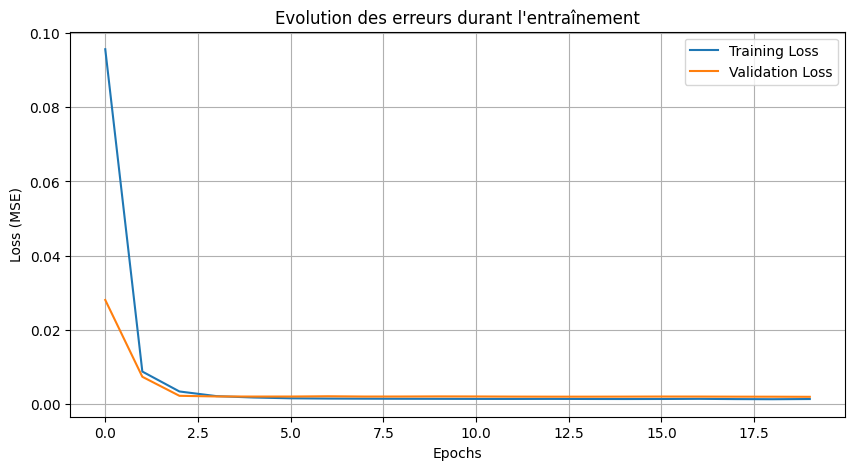

In [ ]:
# Entraînement du modèle RNN
history = model.fit(
    X_train, y_train,          # Données d'entraînement
    epochs=20,                 # Nombre de passes complètes sur le dataset
    batch_size=32,             # Taille des lots pour chaque mise à jour
    validation_data=(X_test, y_test)  # Données de validation
)

# Visualisation des résultats d'entraînement (ajout recommandé)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Evolution des erreurs durant l\'entraînement')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


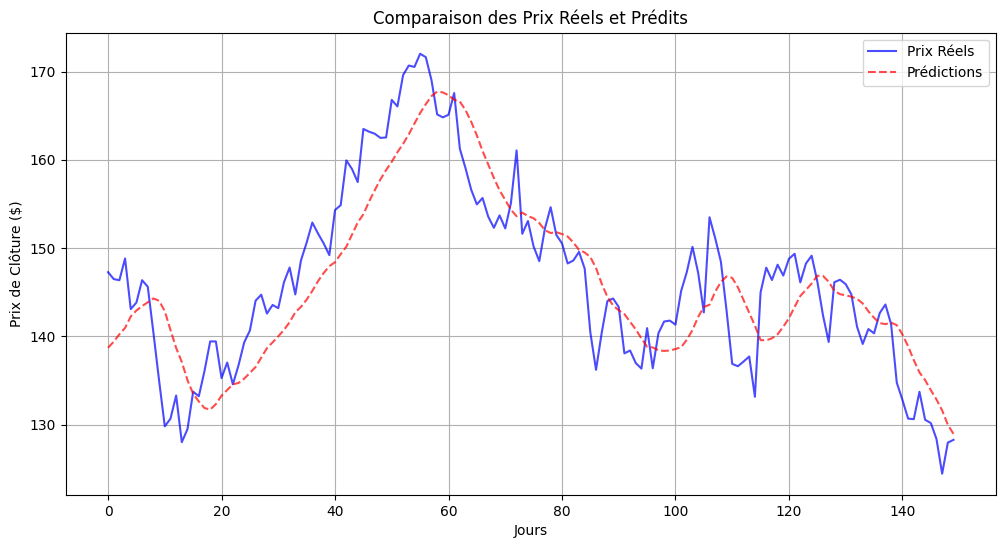

In [ ]:
# Prédiction sur les données de test
pred = model.predict(X_test)

# Transformation inverse pour obtenir les prix réels
pred_prices = scaler.inverse_transform(pred)      # Convertit les prédictions normalisées en prix $
true_prices = scaler.inverse_transform(y_test.reshape(-1, 1))  # Convertit les vraies valeurs

# Visualisation des résultats (ajout recommandé)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(true_prices, label='Prix Réels', color='blue', alpha=0.7)
plt.plot(pred_prices, label='Prédictions', color='red', linestyle='--', alpha=0.7)
plt.title('Comparaison des Prix Réels et Prédits')
plt.xlabel('Jours')
plt.ylabel('Prix de Clôture ($)')
plt.legend()
plt.grid(True)
plt.show()